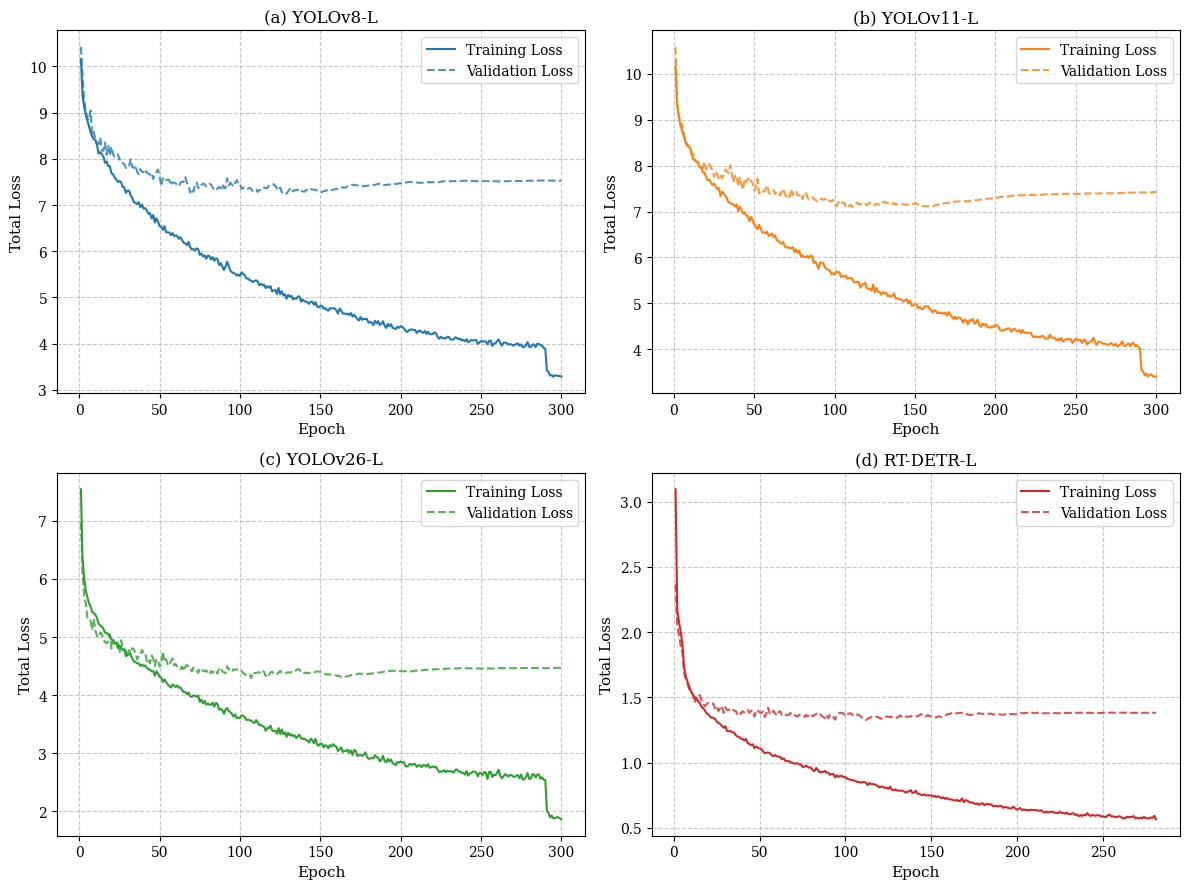

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tentukan path/lokasi file results.csv
path_yolov8 = '../runs/yolov8_20260412_223838/results.csv'
path_yolov11 = '../runs/yolo11_20260413_094445/results.csv'
path_yolov26 = '../runs/yolo26_20260612_224416/results.csv'
path_rtdetr = '../runs/rtdetr_20260416_115723/results.csv'

# 2. Konfigurasi Font Standar Akademik
plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# 3. Baca dan bersihkan data
dfs = {
    'yolov8': pd.read_csv(path_yolov8),
    'yolov11': pd.read_csv(path_yolov11),
    'yolov26': pd.read_csv(path_yolov26),
    'rtdetr': pd.read_csv(path_rtdetr)
}

for name, df in dfs.items():
    df.columns = df.columns.str.strip() # Bersihkan spasi di nama kolom

# 4. Fungsi Menghitung Total Training & Validation Loss
def calculate_losses(df):
    train_loss = pd.Series(0, index=df.index)
    val_loss = pd.Series(0, index=df.index)
    
    # Deteksi format kolom (YOLO vs RT-DETR)
    if 'train/box_loss' in df.columns:
        train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
        # Kolom validasi YOLO biasanya bernama val/box_loss
        val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
    elif 'train/giou_loss' in df.columns:
        train_loss = df['train/giou_loss'] + df['train/cls_loss'] + df['train/l1_loss']
        # Kolom validasi RT-DETR
        val_loss = df['val/giou_loss'] + df['val/cls_loss'] + df['val/l1_loss']
        
    return train_loss, val_loss

# 5. Buat Kanvas Grid 2x2
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
model_configs = [
    (0, 0, 'yolov8', '(a) YOLOv8-L', '#1f77b4'),
    (0, 1, 'yolov11', '(b) YOLOv11-L', '#ff7f0e'),
    (1, 0, 'yolov26', '(c) YOLOv26-L', '#2ca02c'),
    (1, 1, 'rtdetr', '(d) RT-DETR-L', '#d62728')
]

for row, col, key, title, color in model_configs:
    df = dfs[key]
    train_loss, val_loss = calculate_losses(df)
    
    # Plot Training (Garis tegas)
    axs[row, col].plot(df['epoch'], train_loss, color=color, linewidth=1.5, label='Training Loss')
    # Plot Validation (Garis putus-putus)
    axs[row, col].plot(df['epoch'], val_loss, color=color, linewidth=1.5, linestyle='--', alpha=0.8, label='Validation Loss')
    
    axs[row, col].set_title(title)
    axs[row, col].set_xlabel('Epoch')
    axs[row, col].set_ylabel('Total Loss')
    axs[row, col].grid(True, linestyle='--', alpha=0.7)
    axs[row, col].legend()

# 6. Rapikan dan Simpan
plt.tight_layout()
plt.savefig('gambar_4_1_train_val_loss.png', dpi=300, bbox_inches='tight')
plt.show()

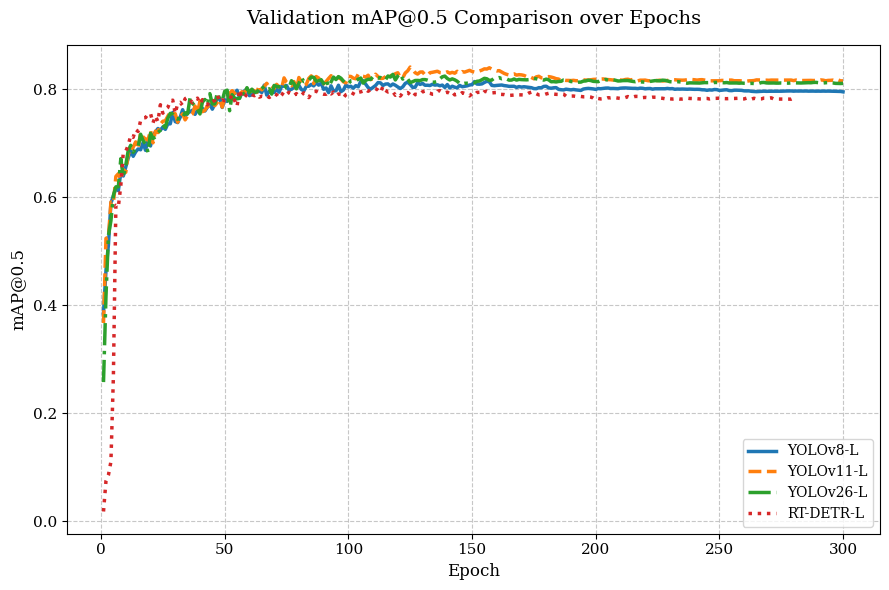

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

path_yolov8 = '../runs/yolov8_20260412_223838/results.csv'
path_yolov11 = '../runs/yolo11_20260413_094445/results.csv'
path_yolov26 = '../runs/yolo26_20260612_224416/results.csv'
path_rtdetr = '../runs/rtdetr_20260416_115723/results.csv'

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

dfs = {
    'YOLOv8-L': pd.read_csv(path_yolov8),
    'YOLOv11-L': pd.read_csv(path_yolov11),
    'YOLOv26-L': pd.read_csv(path_yolov26),
    'RT-DETR-L': pd.read_csv(path_rtdetr)
}

plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
line_styles = ['-', '--', '-.', ':']

for (name, df), color, style in zip(dfs.items(), colors, line_styles):
    df.columns = df.columns.str.strip()
    col_map = 'metrics/mAP50(B)' if 'metrics/mAP50(B)' in df.columns else 'metrics/mAP_0.5'
    plt.plot(df['epoch'], df[col_map], color=color, linestyle=style, linewidth=2.5, label=name)

# Judul dan sumbu menggunakan Bahasa Inggris akademik
plt.title('Validation mAP@0.5 Comparison over Epochs', pad=15)
plt.xlabel('Epoch')
plt.ylabel('mAP@0.5')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right') 

plt.tight_layout()
plt.savefig('figure_4_2_map_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

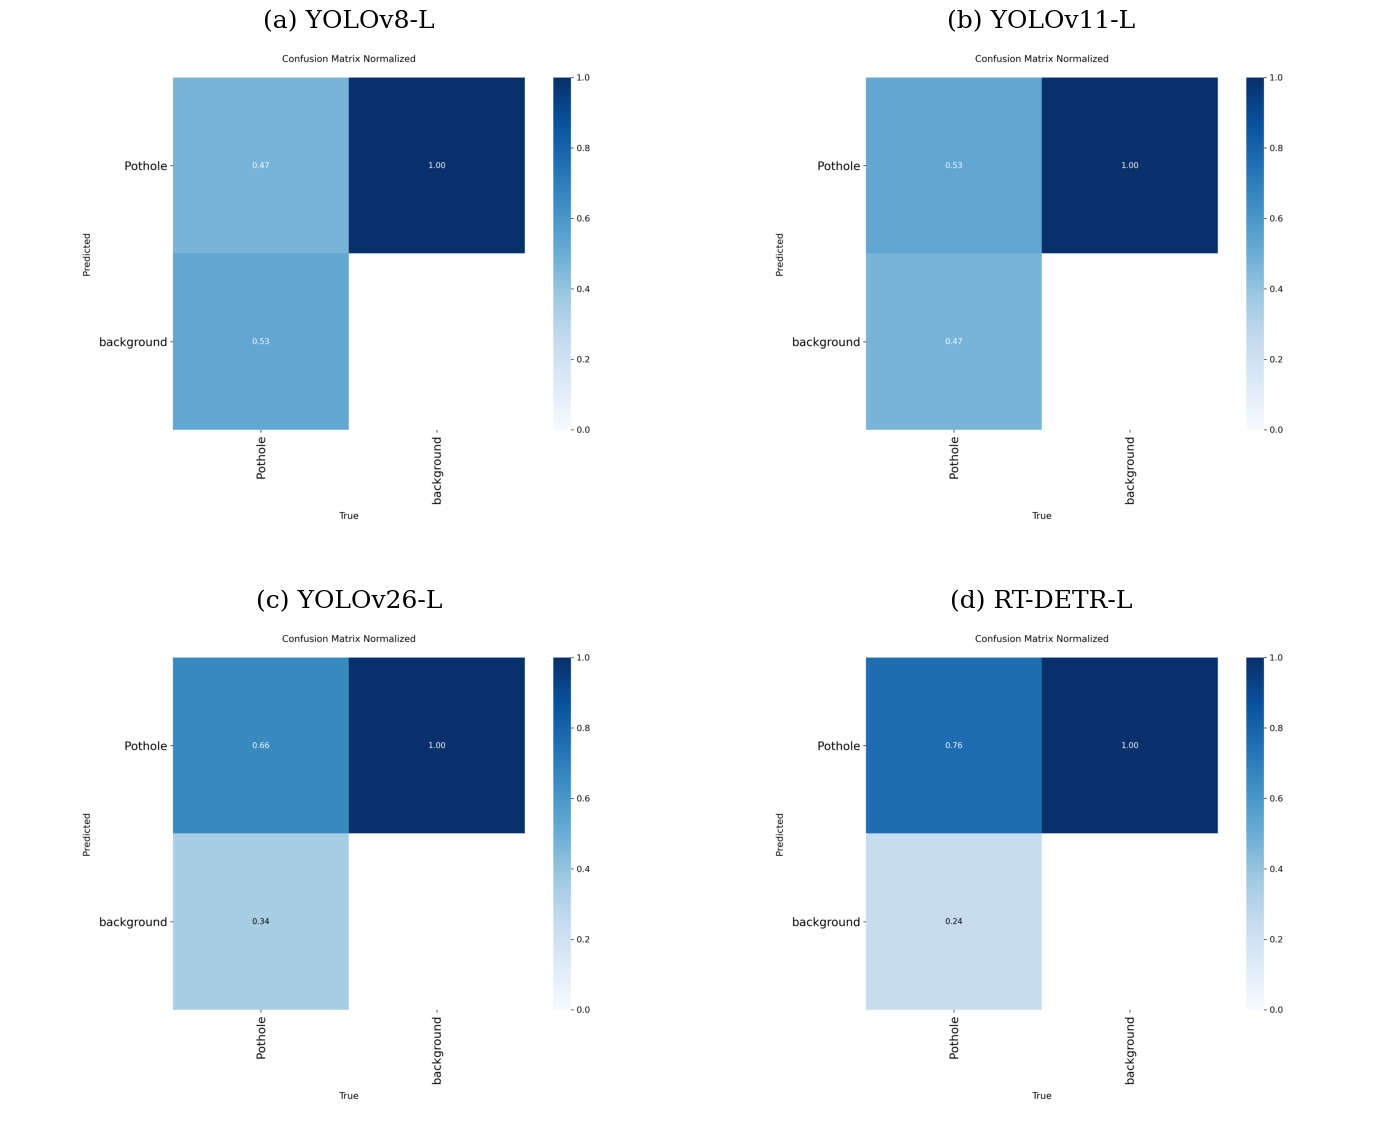

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Atur font agar formal (Serif / Times New Roman style)
plt.rcParams["font.family"] = "serif"

# 2. Tentukan path/lokasi file confusion matrix normalized dari keempat model
path_yolov8 = '../runs/detect/val112/confusion_matrix_normalized.png'
path_yolov11 = '../runs/detect/val113/confusion_matrix_normalized.png'
path_yolov26 = '../runs/detect/val158/confusion_matrix_normalized.png'
path_rtdetr = '../runs/detect/val111/confusion_matrix_normalized.png'

# 3. Baca gambar
img_yolov8  = mpimg.imread(path_yolov8)
img_yolov11 = mpimg.imread(path_yolov11)
img_yolov26 = mpimg.imread(path_yolov26)
img_rtdetr  = mpimg.imread(path_rtdetr)

# 4. Buat kanvas dengan 2 baris dan 2 kolom (Grid 2x2)
# Ukuran figsize diperbesar (14x12) agar teks angka di dalam matriks tetap terbaca jelas
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# --- Grafik (a) YOLOv8 (Kiri Atas) ---
axs[0, 0].imshow(img_yolov8)
axs[0, 0].axis('off') # Sembunyikan garis tepi bawaan matplotlib
axs[0, 0].set_title('(a) YOLOv8-L', fontsize=18, pad=15)

# --- Grafik (b) YOLOv11 (Kanan Atas) ---
axs[0, 1].imshow(img_yolov11)
axs[0, 1].axis('off')
axs[0, 1].set_title('(b) YOLOv11-L', fontsize=18, pad=15)

# --- Grafik (c) YOLOv26 (Kiri Bawah) ---
axs[1, 0].imshow(img_yolov26)
axs[1, 0].axis('off')
axs[1, 0].set_title('(c) YOLOv26-L', fontsize=18, pad=15)

# --- Grafik (d) RT-DETR (Kanan Bawah) ---
axs[1, 1].imshow(img_rtdetr)
axs[1, 1].axis('off')
axs[1, 1].set_title('(d) RT-DETR-L', fontsize=18, pad=15)

# 5. Rapikan tata letak agar tidak saling bertumpuk
plt.tight_layout()

# 6. Simpan dengan resolusi tinggi 300 DPI untuk dicetak di laporan skripsi
plt.savefig('gambar_4_5_confusion_matrix_4model.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import glob

# Konfigurasi
label_dir = "../dataset/combined/train/labels" # Ganti dengan path folder label Anda
pothole_class_id = 0 # Ganti dengan ID kelas pothole di dataset Anda (biasanya 0 jika hanya ada 1 kelas)

total_potholes = 0
total_images_with_potholes = 0

# Mencari semua file .txt di dalam direktori
label_files = glob.glob(os.path.join(label_dir, "*.txt"))

for file_path in label_files:
    has_pothole = False
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            # Memisahkan string berdasarkan spasi dan mengambil elemen pertama (class_id)
            class_id = int(line.split()[0])
            
            if class_id == pothole_class_id:
                total_potholes += 1
                has_pothole = True
                
    if has_pothole:
        total_images_with_potholes += 1

print(f"Total anotasi pothole (bounding boxes): {total_potholes}")
print(f"Total gambar yang memiliki pothole: {total_images_with_potholes}")

Total anotasi pothole (bounding boxes): 1124
Total gambar yang memiliki pothole: 545
